In [2]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [3]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [4]:
# pick 5 colours from the Reds cmap
alpha_colours = plt.cm.Reds(np.linspace(0.4, 1, 5))

# pick 3 colours from the Blues cmap
beta_colours = plt.cm.Blues(np.linspace(0.4, 1, 3))

In [4]:
reload(helpers)
n_parts = 5

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5/qcflag-5", n_parts, label="Fiducial", colour="black"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/alpha-0.0/alpha-0.0", n_parts, label="CE alpha 0.0", colour=alpha_colours[0]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/alpha-0.1/alpha-0.1", n_parts, label="CE alpha 0.1", colour=alpha_colours[1]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/alpha-0.5/alpha-0.5", n_parts, label="CE alpha 0.5", colour=alpha_colours[2]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/alpha-2.0/alpha-2.0", n_parts, label="CE alpha 2.0", colour=alpha_colours[3]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/alpha-10.0/alpha-10.0", n_parts, label="CE alpha 10.0", colour=alpha_colours[4]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/beta-0.0/beta-0.0", n_parts, label="Beta 0.0", colour=beta_colours[0]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/beta-0.5/beta-0.5", n_parts, label="Beta 0.5", colour=beta_colours[1]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/beta-1.0/beta-1.0", n_parts, label="Beta 1.0", colour=beta_colours[2]),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcrit-caseB-0.001/qcrit-caseB-0.001", n_parts, label="qcrit Case B 0.001", colour="tab:pink"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcrit-caseB-1000/qcrit-caseB-1000", n_parts, label="qcrit Case B 1000", colour="tab:purple"),
]

Loading distributed population Fiducial from 5 parts
   loaded part 1/5 of Fiducial with 179379 binaries
   loaded part 2/5 of Fiducial with 178696 binaries
   loaded part 3/5 of Fiducial with 177856 binaries
   loaded part 4/5 of Fiducial with 178671 binaries
   loaded part 5/5 of Fiducial with 179015 binaries
Loading distributed population CE alpha 0.0 from 5 parts
   loaded part 1/5 of CE alpha 0.0 with 187107 binaries
   loaded part 2/5 of CE alpha 0.0 with 186477 binaries
   loaded part 3/5 of CE alpha 0.0 with 185753 binaries
   loaded part 4/5 of CE alpha 0.0 with 186584 binaries
   loaded part 5/5 of CE alpha 0.0 with 186956 binaries
Loading distributed population CE alpha 0.1 from 5 parts
   loaded part 1/5 of CE alpha 0.1 with 185263 binaries
   loaded part 2/5 of CE alpha 0.1 with 184578 binaries
   loaded part 3/5 of CE alpha 0.1 with 183805 binaries
   loaded part 4/5 of CE alpha 0.1 with 184583 binaries
   loaded part 5/5 of CE alpha 0.1 with 184996 binaries
Loading distr

In [5]:
pop.kick_info.loc[3]

NameError: name 'pop' is not defined

In [ ]:
disrupts

1          1.0
3          1.0
4          1.0
5          1.0
13         1.0
          ... 
1589273    1.0
1589274    1.0
1589275    1.0
1589276    1.0
1589279    1.0
Name: disrupted, Length: 889182, dtype: float64

In [ ]:
for pop in pops:
    disrupts = pop.kick_info[pop.kick_info["star"] != 0.0].drop_duplicates(subset="bin_num", keep="first")["disrupted"]
    f_disrupt_at_first_SN = len(disrupts[disrupts == 1.0]) / len(pop.bin_nums)
    print(f"{pop.label}: Fraction disrupted at first SN: {f_disrupt_at_first_SN:.3f}")

    first_SN_rows = pop.bpp[pop.bpp["evol_type"].isin([15, 16])].drop_duplicates(subset="bin_num", keep="first")
    merger_before_first_SN = first_SN_rows["bin_num"][first_SN_rows["sep"] == 0.0].unique()

    kick_info = pop.kick_info[~pop.kick_info["bin_num"].isin(merger_before_first_SN)]
    disrupts = kick_info[kick_info["star"] != 0.0].drop_duplicates(subset="bin_num", keep="first")["disrupted"]
    f_disrupt_at_first_SN = len(disrupts[disrupts == 1.0]) / len(pop.bin_nums)

    print(f"   After removing pre-SN mergers: Fraction disrupted at first SN: {f_disrupt_at_first_SN:.3f}")

Fiducial: Fraction disrupted at first SN: 0.967
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.215
CE alpha 0.0: Fraction disrupted at first SN: 0.984
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.174
CE alpha 0.1: Fraction disrupted at first SN: 0.977
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.179
CE alpha 0.5: Fraction disrupted at first SN: 0.970
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.202
CE alpha 2.0: Fraction disrupted at first SN: 0.959
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.226
CE alpha 10.0: Fraction disrupted at first SN: 0.952
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.257
Beta 0.0: Fraction disrupted at first SN: 0.965
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.235
Beta 0.5: Fraction disrupted at first SN: 0.966
   After removing pre-SN mergers: Fraction disrupted at first SN: 0.228
Beta 1.0: Fraction 

In [ ]:
kinematics = helpers.get_kinematics(pops)

[ 3.06315596 10.59611709 20.25102946 23.20433692]
[ 2.99247997 10.40912647 20.60093798 22.97896683]
[ 2.82891248  9.71790562 19.25538491 21.19944348]
[ 2.92318786 10.12776487 19.5066884  22.34620342]
[ 2.91285151 10.25910366 19.83352008 21.27701723]
[ 2.74959009  9.74720238 18.56900064 20.54309051]
[ 2.75413167  9.85227092 19.13567688 20.3934343 ]
[ 3.2052236  11.61538502 21.96388738 24.0784187 ]
[ 2.51920071  8.82034289 17.31621078 18.40240489]
[ 2.64287777  9.25014093 17.88447305 19.59437007]
[ 2.79987681  9.93554159 18.85644471 21.54217391]


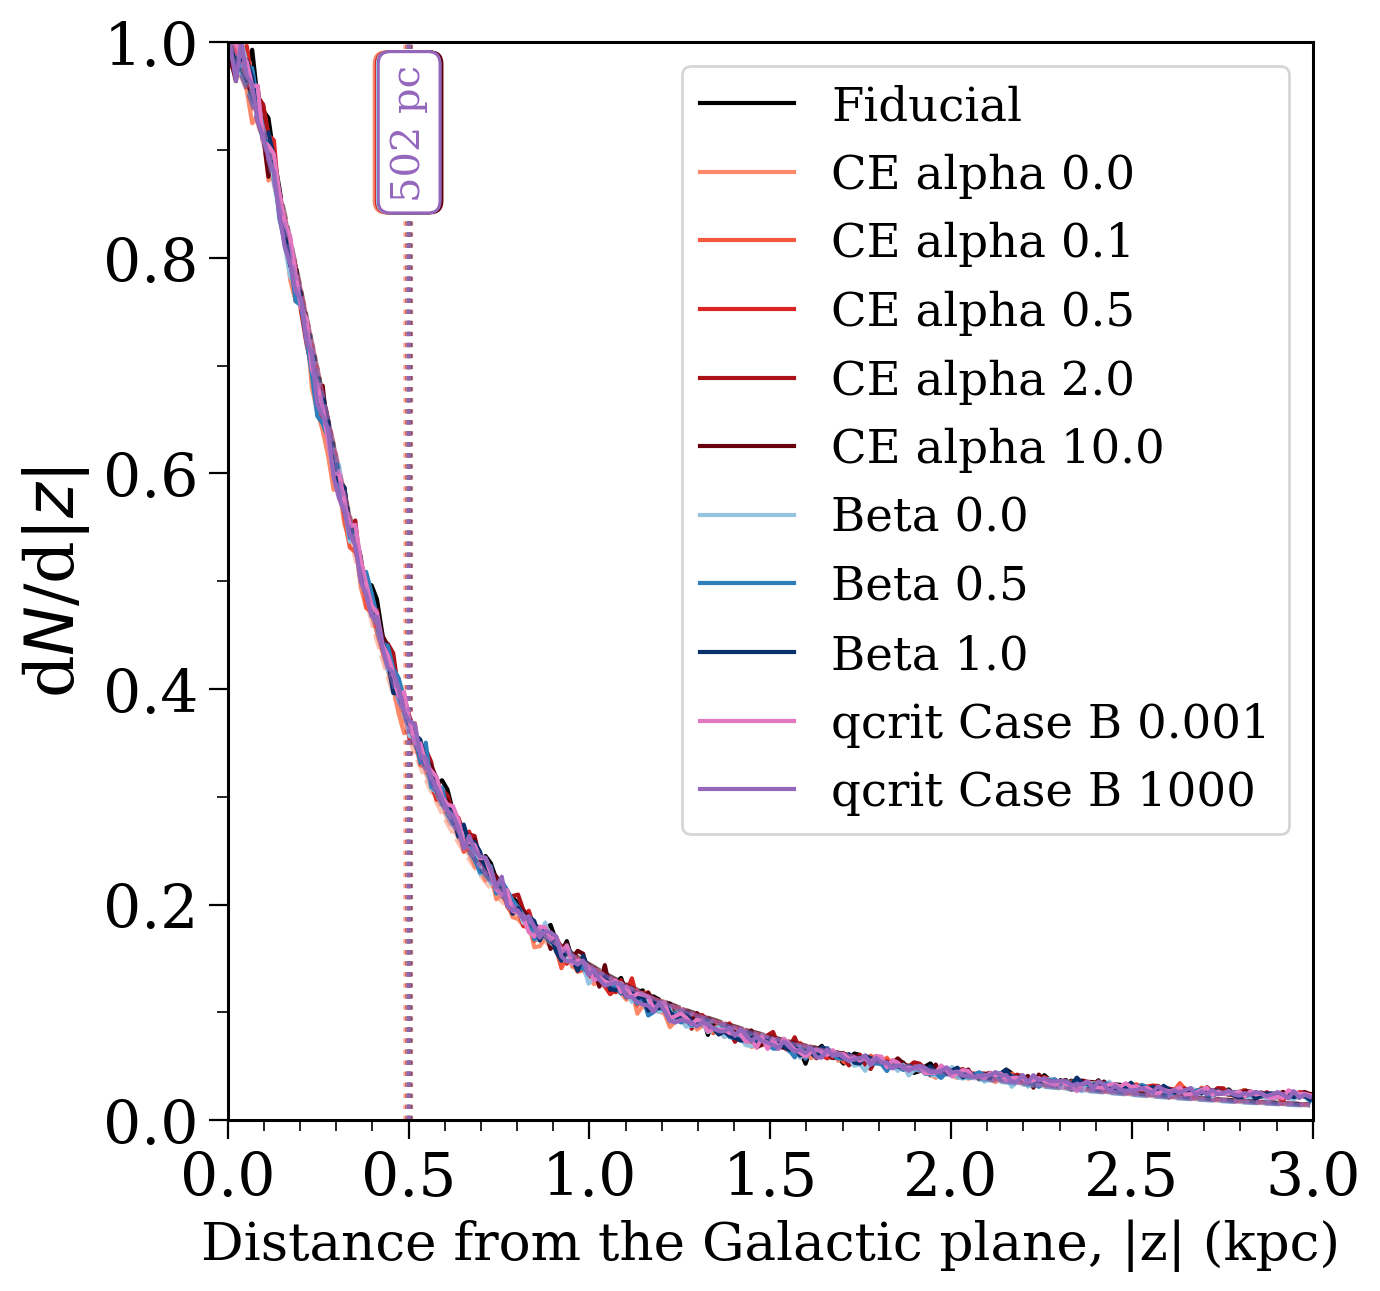

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

for pop in pops:
    scale_height, _, _ = plotting.estimate_scale_height(
        z=kinematics[pop.label]["pos"]["BH"][:, 2][~kinematics[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[0.98]
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
scale_up = 6e10 / pops[0].mass_binaries

In [ ]:
ns_totals = np.zeros(len(pops))
bh_totals = np.zeros(len(pops))

ns_mass_totals = np.zeros(len(pops))
bh_mass_totals = np.zeros(len(pops))

for i, pop in enumerate(pops):
    n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
    n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
    print(f"  Scaled totals: {(n_ns + n_bh) * scale_up:1.1e}, NSs: {n_ns * scale_up:1.1e}, BHs: {n_bh * scale_up:1.1e}")

    ns_totals[i] = n_ns * scale_up
    bh_totals[i] = n_bh * scale_up

    ns_mass_totals[i] = (pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13].sum() + pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13].sum()) * scale_up
    bh_mass_totals[i] = (pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14].sum() + pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14].sum()) * scale_up

Fiducial
  Total: 995652, NSs: 717975, BHs: 277677
  Scaled totals: 6.6e+08, NSs: 4.7e+08, BHs: 1.8e+08
$\alpha_{\rm CE} = 0.0$
  Total: 1019872, NSs: 727962, BHs: 291910
  Scaled totals: 6.7e+08, NSs: 4.8e+08, BHs: 1.9e+08
$\alpha_{\rm CE} = 0.1$
  Total: 1014124, NSs: 726268, BHs: 287856
  Scaled totals: 6.7e+08, NSs: 4.8e+08, BHs: 1.9e+08
$\alpha_{\rm CE} = 0.5$
  Total: 1008941, NSs: 726089, BHs: 282852
  Scaled totals: 6.7e+08, NSs: 4.8e+08, BHs: 1.9e+08
$\alpha_{\rm CE} = 2.0$
  Total: 992710, NSs: 725278, BHs: 267432
  Scaled totals: 6.6e+08, NSs: 4.8e+08, BHs: 1.8e+08
$\alpha_{\rm CE} = 10.0$
  Total: 988170, NSs: 737576, BHs: 250594
  Scaled totals: 6.5e+08, NSs: 4.9e+08, BHs: 1.7e+08
$\beta = 0.0$
  Total: 913315, NSs: 648421, BHs: 264894
  Scaled totals: 6.0e+08, NSs: 4.3e+08, BHs: 1.8e+08
$\beta = 0.5$
  Total: 945473, NSs: 675281, BHs: 270192
  Scaled totals: 6.2e+08, NSs: 4.5e+08, BHs: 1.8e+08
$\beta = 1.0$
  Total: 996742, NSs: 719074, BHs: 277668
  Scaled totals: 6.6e+0

In [ ]:
labels = ["Fiducial", r"$\alpha_{\rm CE} = 0.0$", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
          r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$q_{\rm crit, B} = 10^{-3}$", r"$q_{\rm crit, B} = 10^{3}$"]
for l, p in zip(labels, pops):
    p.label = l

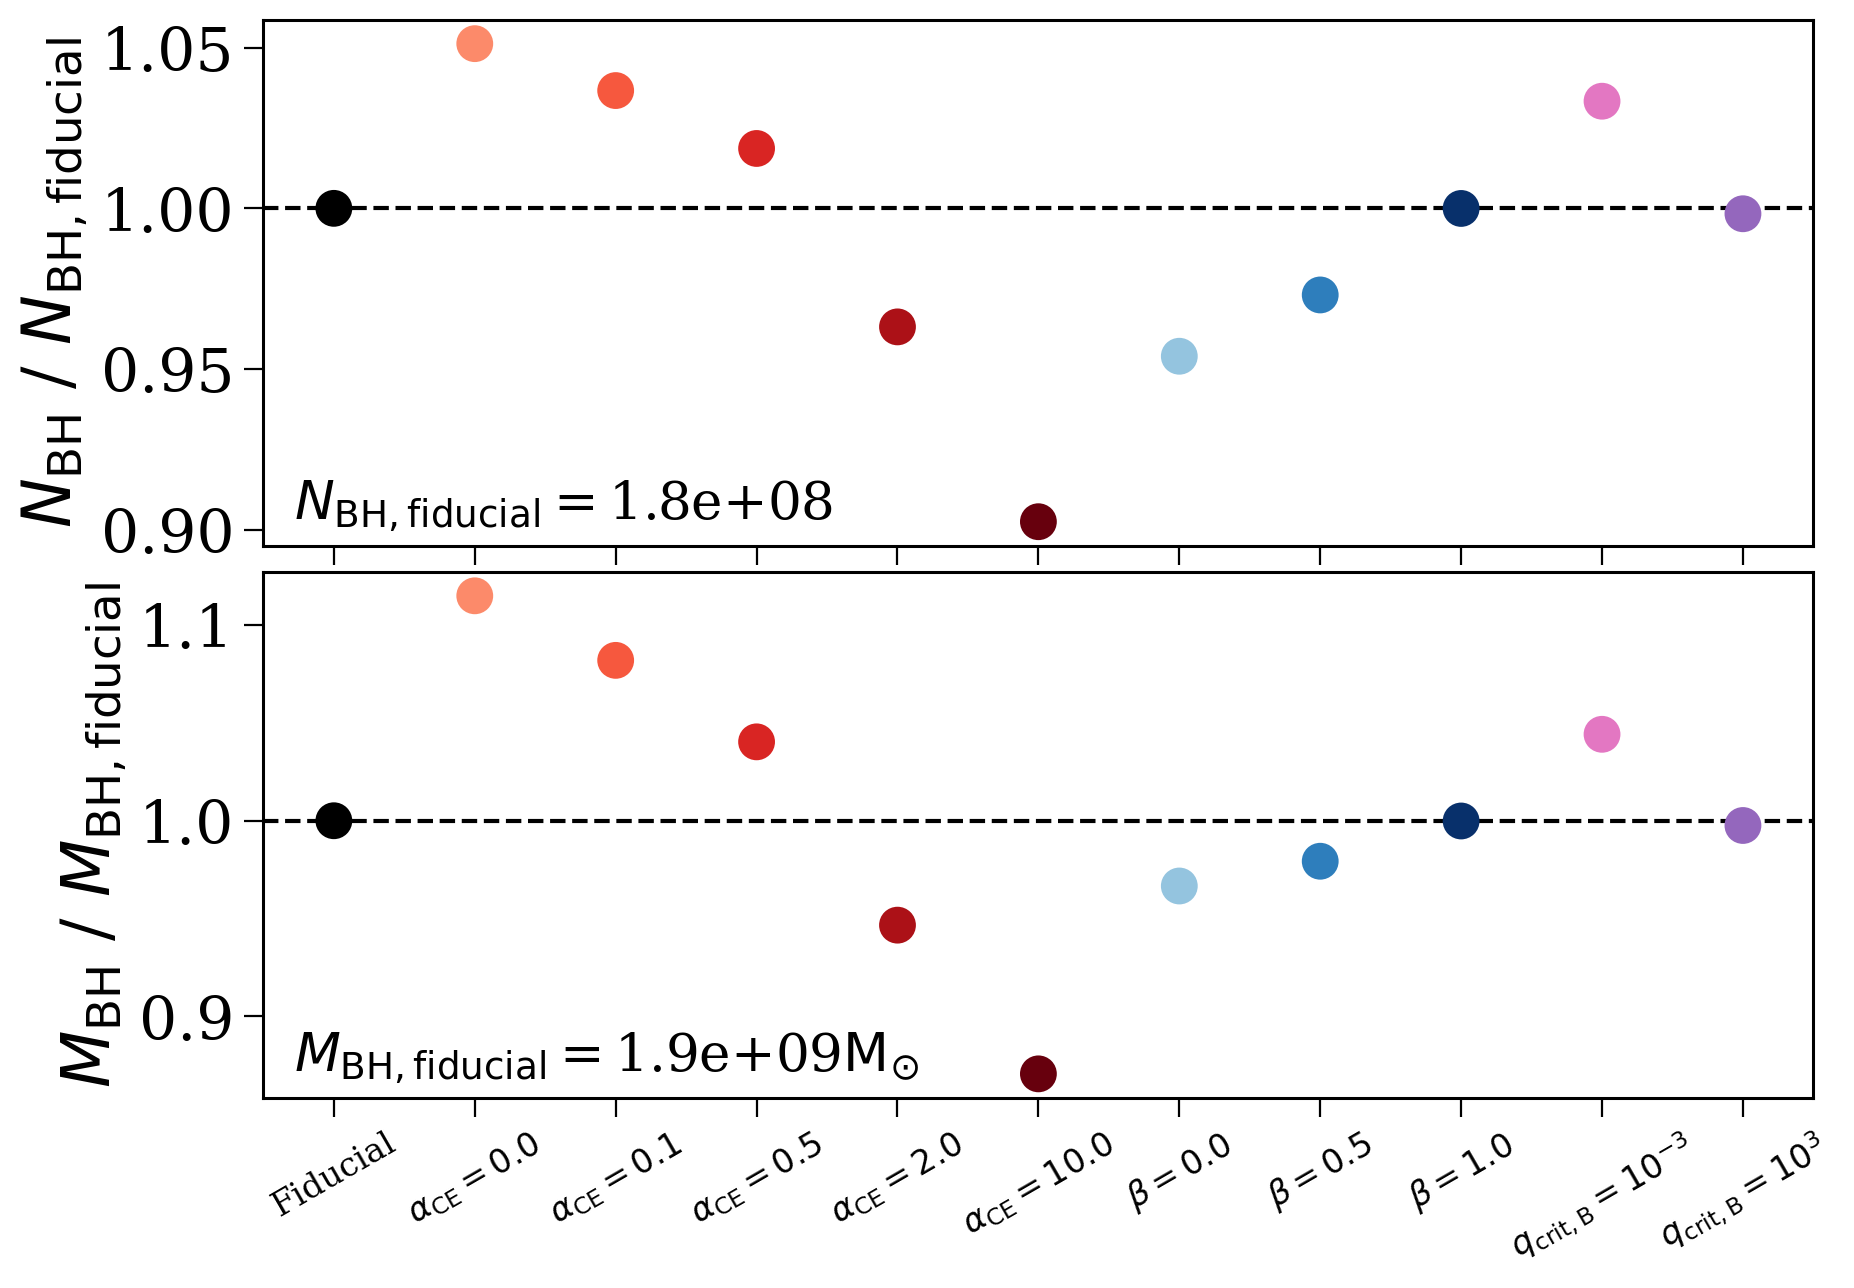

In [ ]:
labels = [pop.label for pop in pops]
colours = [pop.colour for pop in pops]

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

fig.subplots_adjust(hspace=0.05)

axes[0].scatter(labels, bh_totals / bh_totals[0], c=colours, s=150)
axes[0].axhline(1, color='black', linestyle='--', zorder=-1)
axes[0].annotate("$N_{\\rm{BH, fiducial}} = $" + f"{bh_totals[0]:.1e}", xy=(0.02, 0.05), xycoords='axes fraction', fontsize=0.8*fs)

axes[1].scatter(labels, bh_mass_totals / bh_mass_totals[0], c=colours, s=150)
axes[1].axhline(1, color='black', linestyle='--', zorder=-1)
axes[1].annotate("$M_{\\rm{BH, fiducial}} = $" + f"{bh_mass_totals[0]:.1e}" + "$\\rm M_{\\odot}$", xy=(0.02, 0.05), xycoords='axes fraction', fontsize=0.8*fs)

axes[0].set_xticklabels([])

axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)

axes[0].set_ylabel("$N_{\\rm{BH}}$ / $N_{\\rm{BH, fiducial}}$", fontsize=fs)
axes[1].set_ylabel("$M_{\\rm{BH}}$ / $M_{\\rm{BH, fiducial}}$", fontsize=fs)

plt.savefig("../plots/total_bh_number_and_mass_MT_variations.pdf", format="pdf", bbox_inches="tight")

plt.show()

/tmp/ipykernel_219660/1740407754.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)


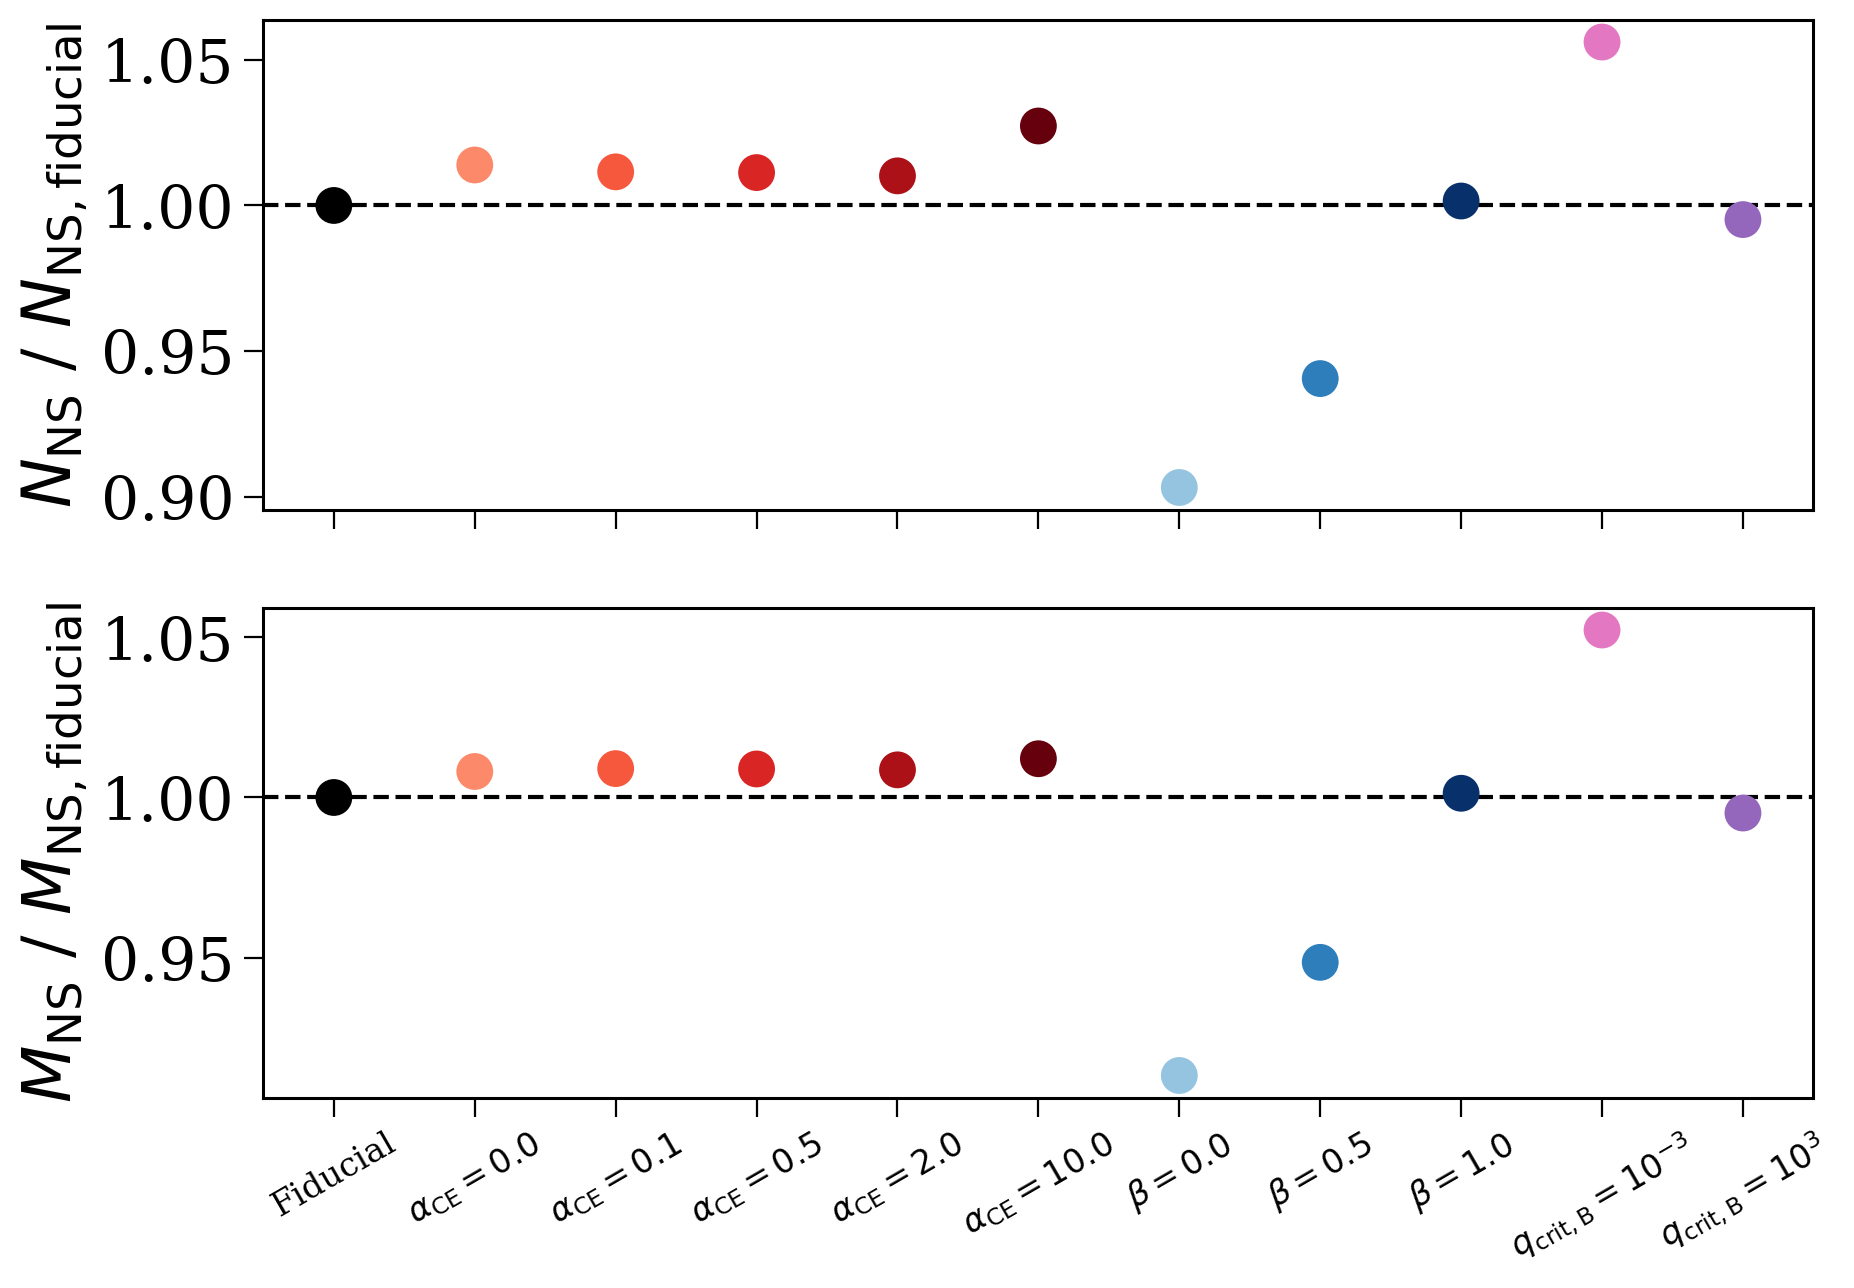

In [ ]:
labels = [pop.label for pop in pops]
colours = [pop.colour for pop in pops]

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].scatter(labels, ns_totals / ns_totals[0], c=colours, s=150)
axes[0].axhline(1, color='black', linestyle='--', zorder=-1)

axes[1].scatter(labels, ns_mass_totals / ns_mass_totals[0], c=colours, s=150)
axes[1].axhline(1, color='black', linestyle='--', zorder=-1)

axes[0].set_xticklabels([])
axes[1].set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)

axes[0].set_ylabel("$N_{\\rm{NS}}$ / $N_{\\rm{NS, fiducial}}$", fontsize=fs)
axes[1].set_ylabel("$M_{\\rm{NS}}$ / $M_{\\rm{NS, fiducial}}$", fontsize=fs)

plt.show()

Inner 10 kpc
  Fiducial fraction within 0.5 kpc 0.49
  CE alpha 0.0 fraction within 0.5 kpc 0.48
  CE alpha 0.1 fraction within 0.5 kpc 0.48
  CE alpha 0.5 fraction within 0.5 kpc 0.49
  CE alpha 2.0 fraction within 0.5 kpc 0.49
  CE alpha 10.0 fraction within 0.5 kpc 0.50
  Beta 0.0 fraction within 0.5 kpc 0.47
  Beta 0.5 fraction within 0.5 kpc 0.47
  Beta 1.0 fraction within 0.5 kpc 0.49
  qcrit Case B 0.001 fraction within 0.5 kpc 0.45
  qcrit Case B 1000 fraction within 0.5 kpc 0.49
Full population
  Fiducial fraction within 0.5 kpc 0.39
  CE alpha 0.0 fraction within 0.5 kpc 0.38
  CE alpha 0.1 fraction within 0.5 kpc 0.38
  CE alpha 0.5 fraction within 0.5 kpc 0.39
  CE alpha 2.0 fraction within 0.5 kpc 0.39
  CE alpha 10.0 fraction within 0.5 kpc 0.40
  Beta 0.0 fraction within 0.5 kpc 0.36
  Beta 0.5 fraction within 0.5 kpc 0.37
  Beta 1.0 fraction within 0.5 kpc 0.39
  qcrit Case B 0.001 fraction within 0.5 kpc 0.35
  qcrit Case B 1000 fraction within 0.5 kpc 0.39


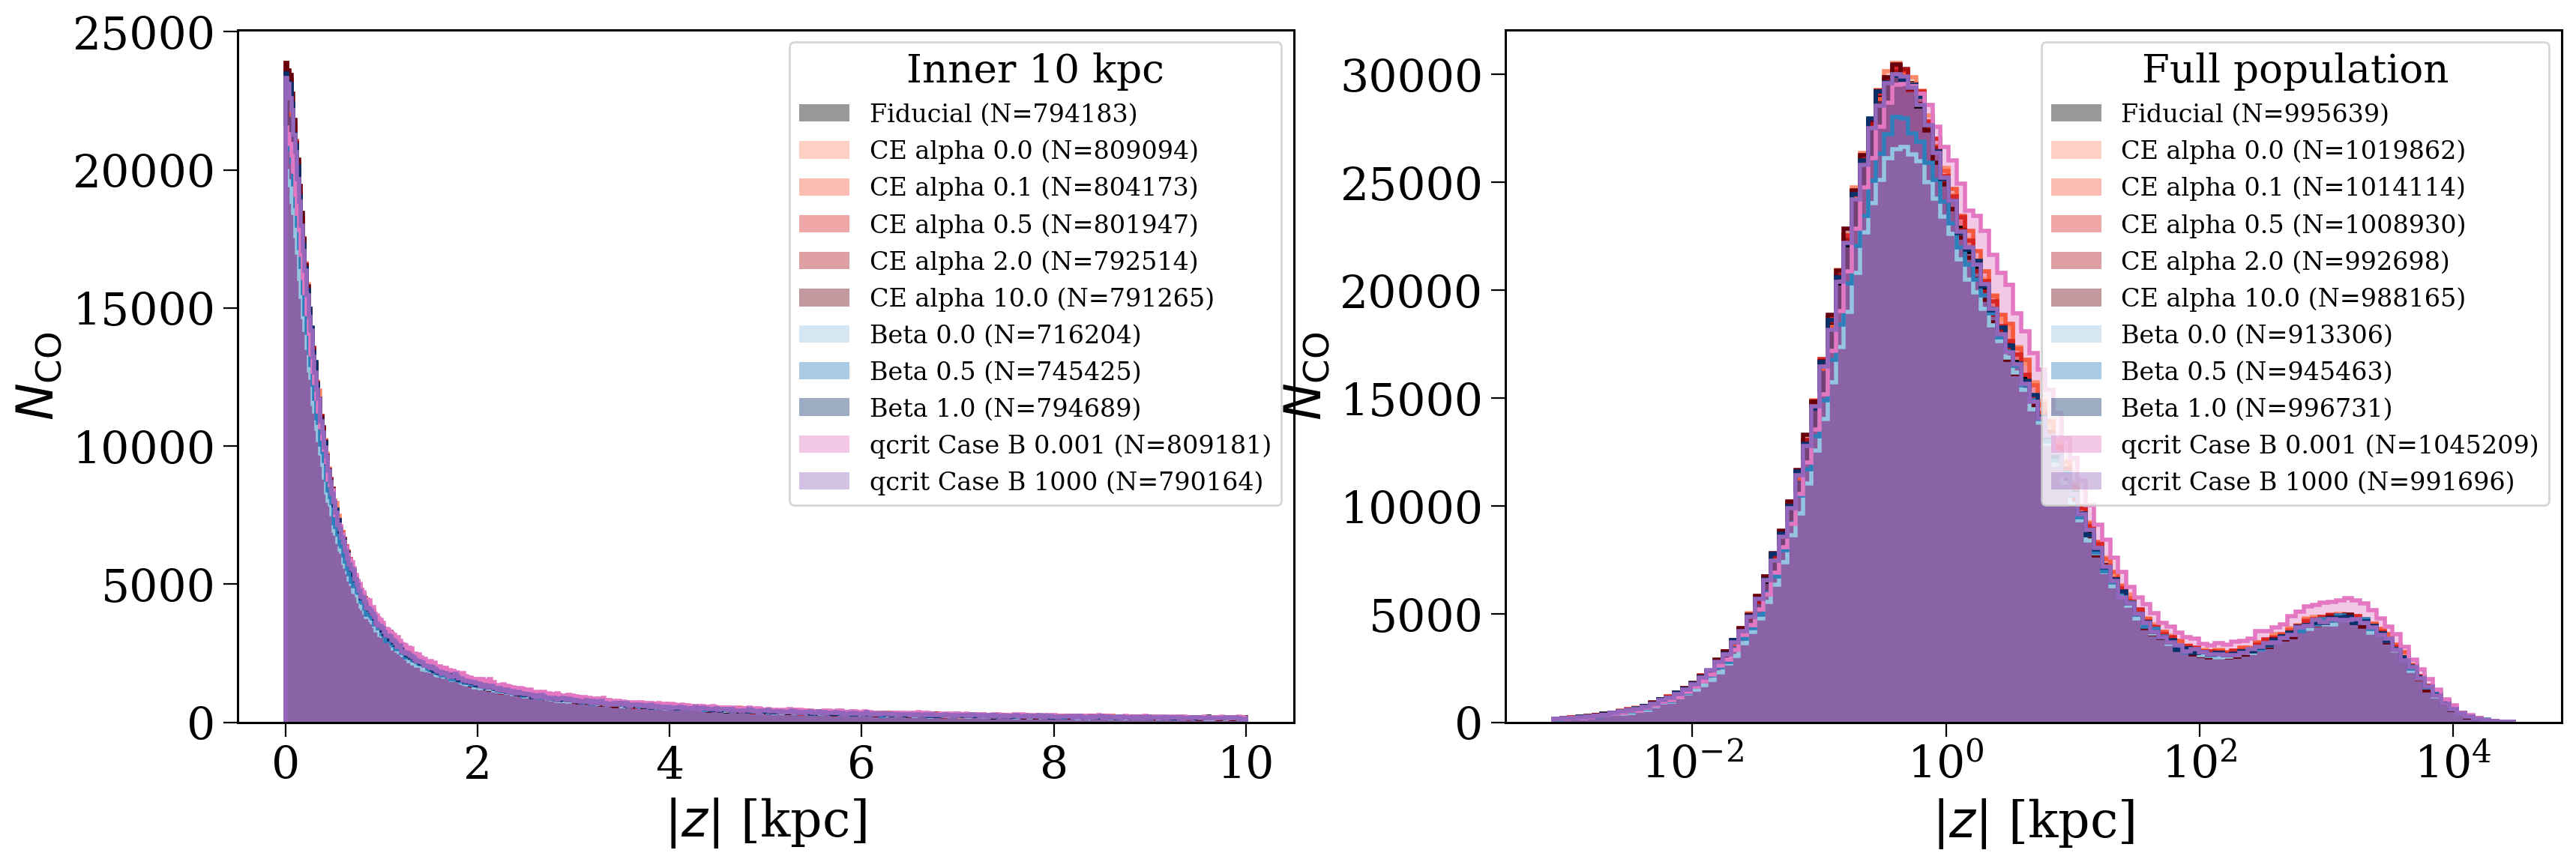

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [ ]:
plotting.absolute_galactocentric_height(pops, kinematics)

In [ ]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Fiducial:
      - CO = 0.107
      - BH = 0.029
      - NS = 0.137
  - $\alpha_{\rm CE} = 0.0$:
      - CO = 0.108
      - BH = 0.031
      - NS = 0.139
  - $\alpha_{\rm CE} = 0.1$:
      - CO = 0.108
      - BH = 0.030
      - NS = 0.139
  - $\alpha_{\rm CE} = 0.5$:
      - CO = 0.107
      - BH = 0.029
      - NS = 0.138
  - $\alpha_{\rm CE} = 2.0$:
      - CO = 0.106
      - BH = 0.027
      - NS = 0.135
  - $\alpha_{\rm CE} = 10.0$:
      - CO = 0.105
      - BH = 0.026
      - NS = 0.132
  - $\beta = 0.0$:
      - CO = 0.113
      - BH = 0.028
      - NS = 0.148
  - $\beta = 0.5$:
      - CO = 0.111
      - BH = 0.028
      - NS = 0.145
  - $\beta = 1.0$:
      - CO = 0.106
      - BH = 0.029
      - NS = 0.136
  - $q_{\rm crit, B} = 10^{-3}$:
      - CO = 0.119
      - BH = 0.028
      - NS = 0.154
  - $q_{\rm crit, B} = 10^{3}$:
      - CO = 0.107
      - BH = 0.028
      - NS = 0.137


In [ ]:
higher_mass_bhs = pops[4].final_bpp[(((pops[4].final_bpp['kstar_1'] == 14) & (pops[4].final_bpp['mass_1'] > 10)) | ((pops[4].final_bpp['kstar_2'] == 14) & (pops[4].final_bpp['mass_2'] > 10))) & (pops[4].initC["metallicity"] >= 0.0142)]

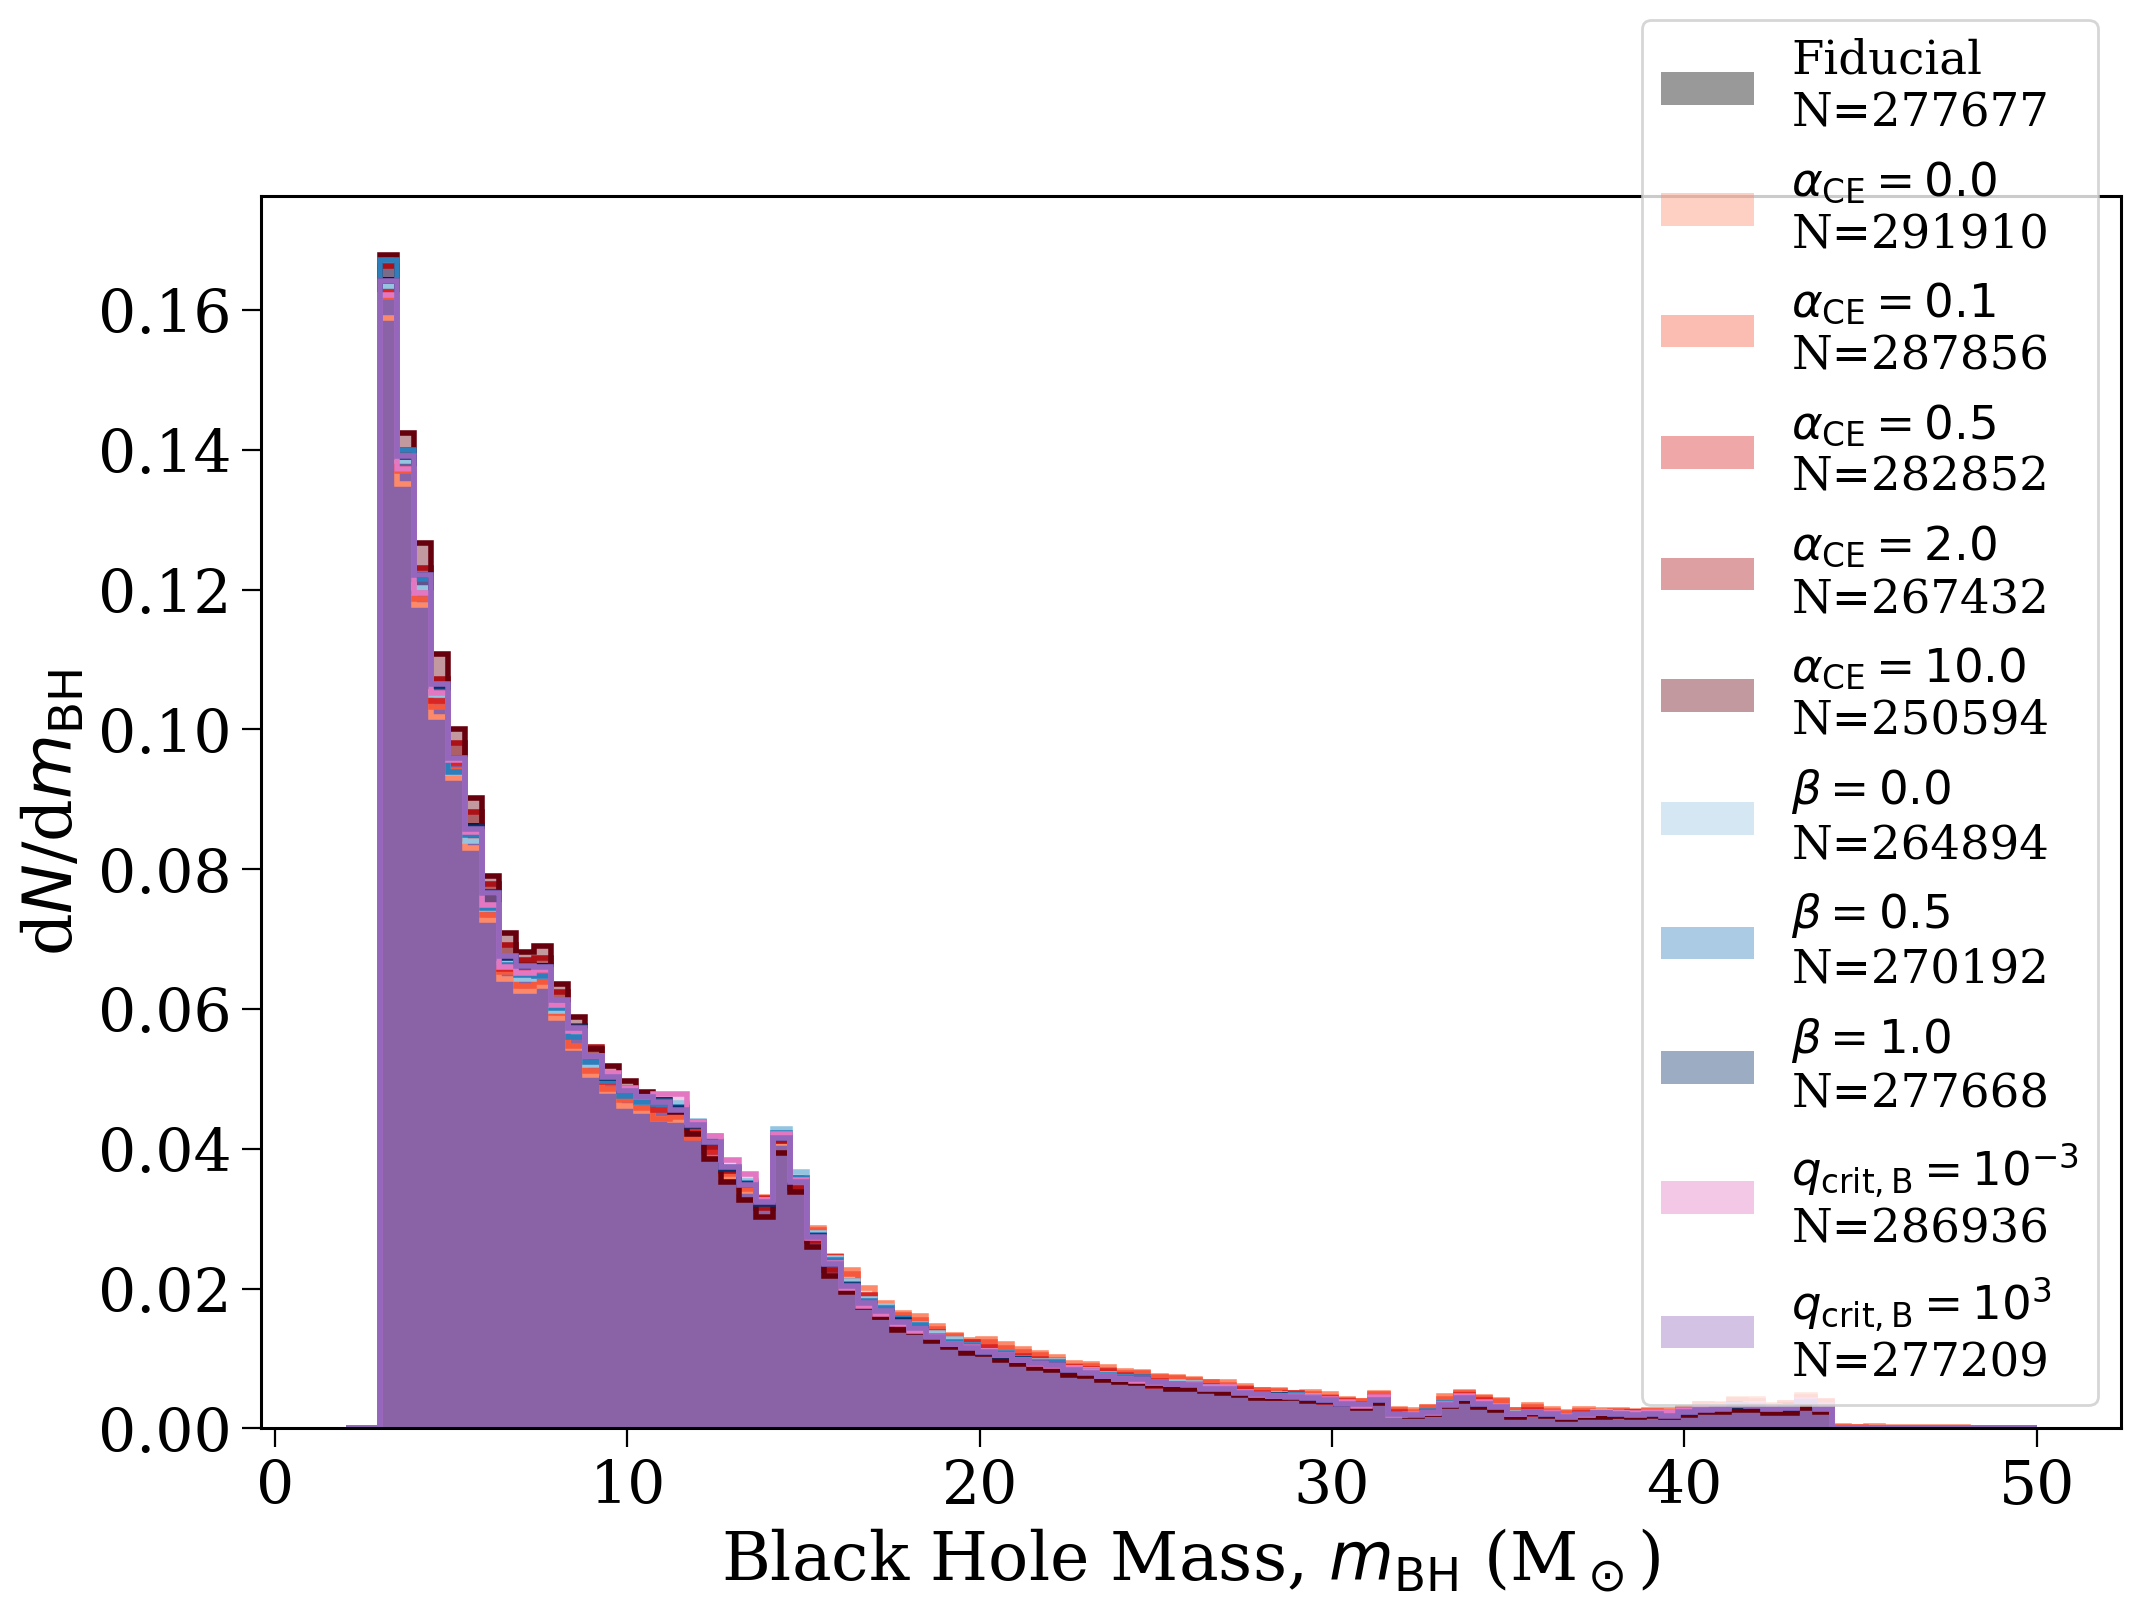

In [ ]:
fig, ax = plotting.compare_table_quantity(
    pops=[p for p in pops if "Maltsev" not in p.label],
    quantity="mass",
    kstar=14,
    bins=np.linspace(2, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)
plt.show()

In [ ]:
masses = {}

for pop in pops:
    mass = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    mass["CO"] = np.concatenate((mass["NS"], mass["BH"]))
    masses[pop.label] = mass

In [ ]:
z_range = np.geomspace(0.1, 10, 1000)

init_bh_z = np.concatenate((
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_1"] == 14],
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_2"] == 14]
))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value)
            for pop in pops] + [init_abs_z],
    bh_masses=[masses[pop.label]["BH"] for pop in pops] + [masses[pops[0].label]["BH"]],
    z_range=z_range,
    window_width=0.1
)

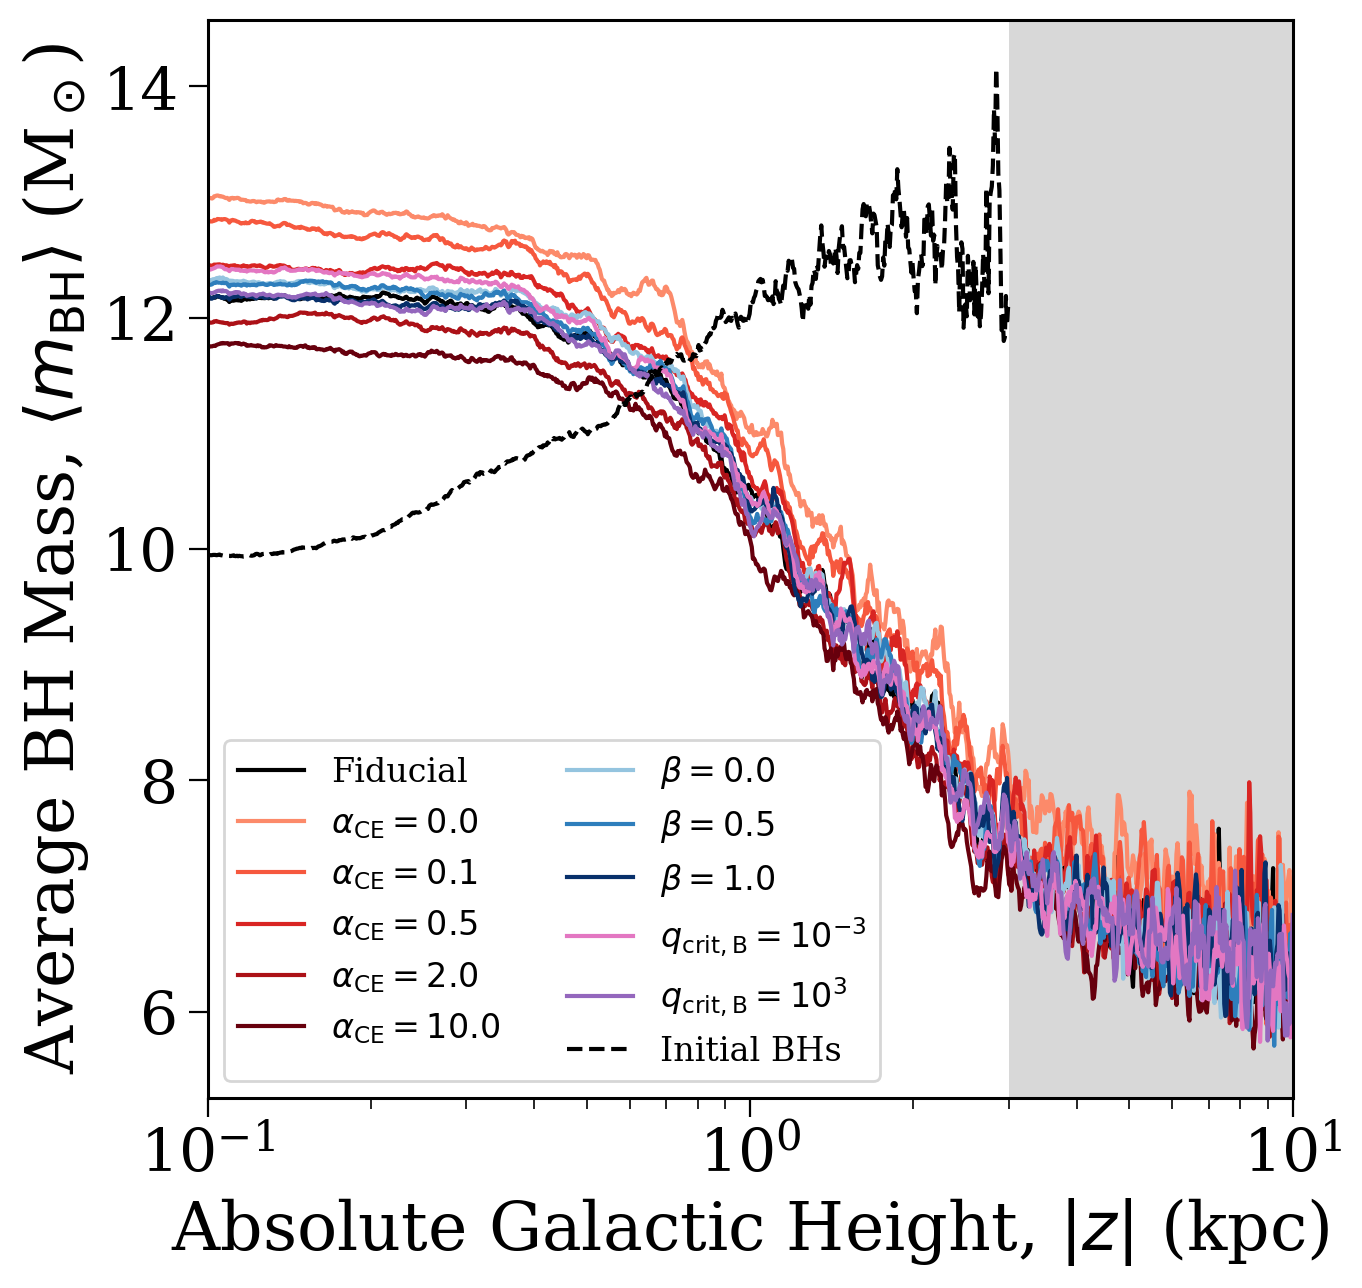

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="black", linestyle='--')

ax.axvspan(3, 10, color='grey', alpha=0.3, lw=0)

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average BH Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

ax.legend(fontsize=0.5*fs, ncol=2, loc='lower left')

plt.savefig("../plots/mean_bh_mass_vs_z_MT_variations.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
bns_mergers = np.zeros(len(pops))

for i, pop in enumerate(pops):

    bns_binary = (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14) & (pop.bpp["sep"] > 0.0)
    bns_binary_nums = pop.bpp[bns_binary]["bin_num"].values

    merged_at_present_nums = pop.bin_nums[pop.final_bpp["sep"] == 0.0]

    bns_merger_nums = np.intersect1d(bns_binary_nums, merged_at_present_nums)
    bns_mergers[i] = len(bns_merger_nums)
    print(f"{pop.label}: Number of BNS mergers at present: {len(bns_merger_nums)}")

Fiducial: Number of BNS mergers at present: 287
$\alpha_{\rm CE} = 0.0$: Number of BNS mergers at present: 0
$\alpha_{\rm CE} = 0.1$: Number of BNS mergers at present: 462
$\alpha_{\rm CE} = 0.5$: Number of BNS mergers at present: 277
$\alpha_{\rm CE} = 2.0$: Number of BNS mergers at present: 225
$\alpha_{\rm CE} = 10.0$: Number of BNS mergers at present: 73
$\beta = 0.0$: Number of BNS mergers at present: 375
$\beta = 0.5$: Number of BNS mergers at present: 264
$\beta = 1.0$: Number of BNS mergers at present: 285
$q_{\rm crit, B} = 10^{-3}$: Number of BNS mergers at present: 170
$q_{\rm crit, B} = 10^{3}$: Number of BNS mergers at present: 306


/tmp/ipykernel_219660/1345778857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)
/tmp/ipykernel_219660/1345778857.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)


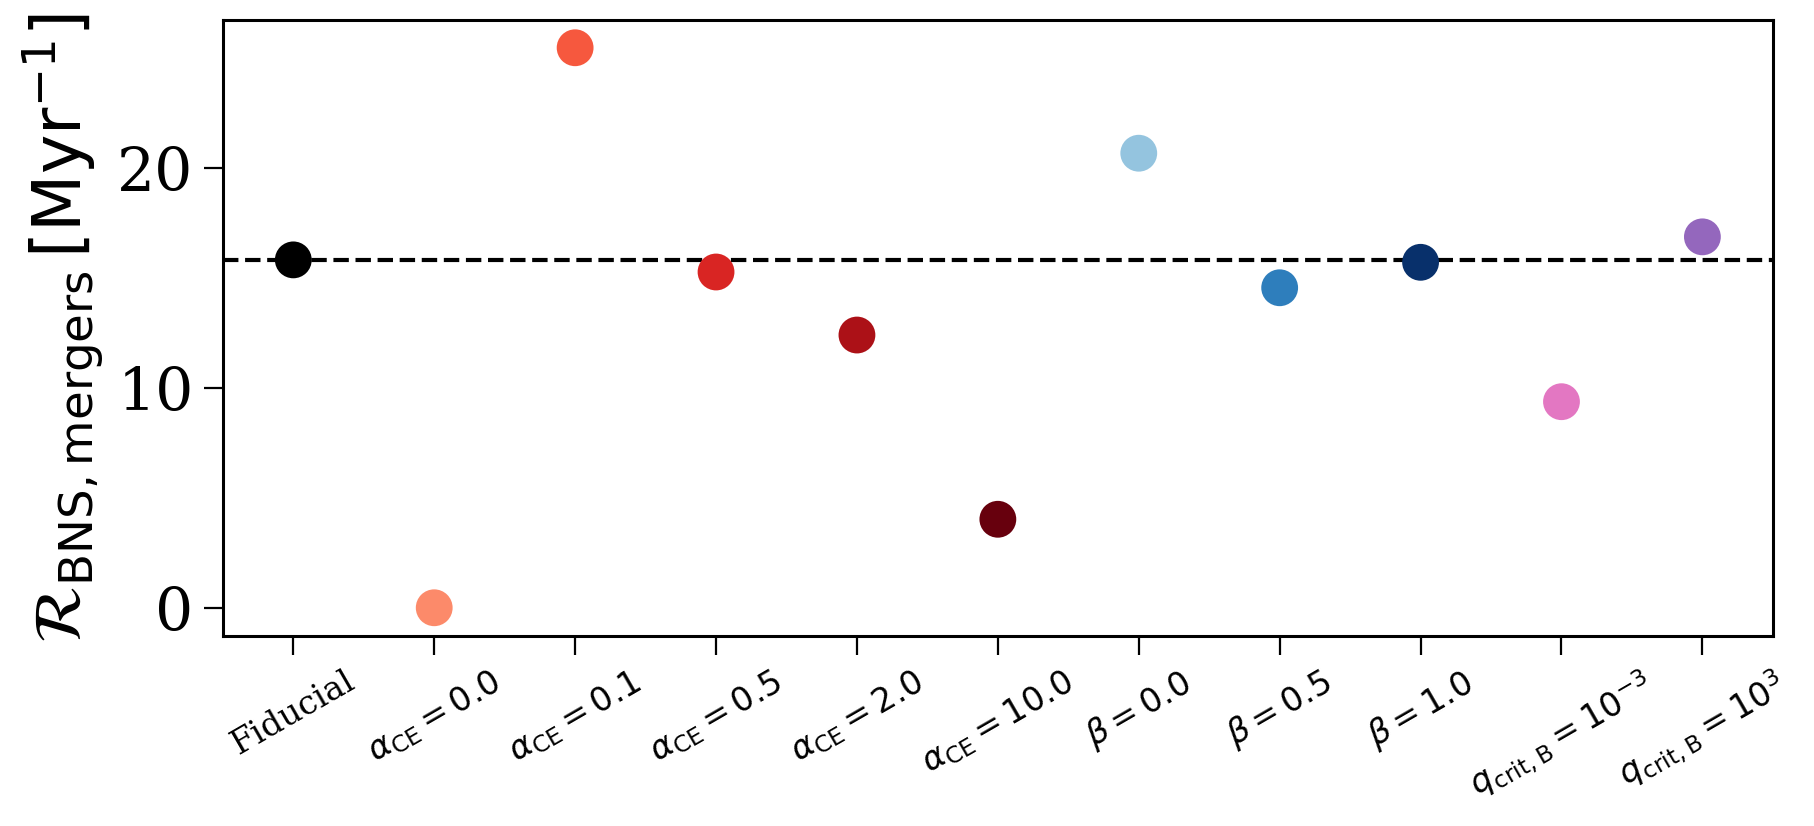

In [ ]:
labels = [pop.label for pop in pops]
colours = [pop.colour for pop in pops]

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(labels, bns_mergers * scale_up / 12000, c=colours, s=150)
ax.axhline(bns_mergers[0] * scale_up / 12000, color='black', linestyle='--', zorder=-1)
ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)
ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)

ax.set_ylabel("$\mathcal{R}_{\\rm{BNS, mergers}} \, [\\rm Myr^{-1}]$", fontsize=fs)

# ax.set_yticks([0, 50000, 100000, 150000, 200000, 250000, 300000])
# ax.set_yticklabels([0, 50000, 100000, 150000, 200000, 250000, 300000])

# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(25000))

plt.show()